## Import

In [9]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)
print("TensorFlow Version:", tf.__version__)

OpenCV Version: 4.13.0
TensorFlow Version: 2.21.0


## Dokumentasi

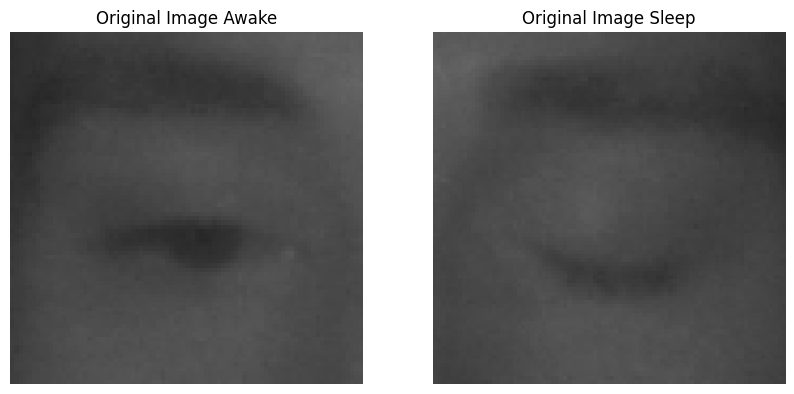

In [10]:
sample_path = "data/train/awake/s0001_01842_0_0_1_0_0_01.png"
sample_sleep= "data/train/sleepy/s0001_00002_0_0_0_0_0_01.png"
img1 = cv2.imread(sample_path)
img2 = cv2.imread(sample_sleep)

img_rgb1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img_rgb2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb1)
plt.title("Original Image Awake")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(img_rgb2)
plt.title("Original Image Sleep")
plt.axis("off")
plt.show()

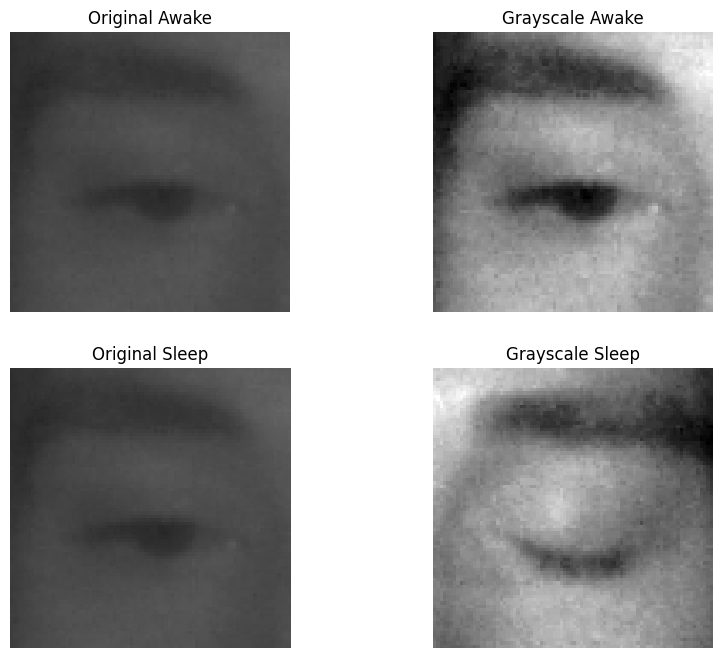

In [11]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img_rgb1)
plt.title("Original Awake")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray1,cmap='gray')
plt.title("Grayscale Awake")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(img_rgb1)
plt.title("Original Sleep")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(gray2,cmap='gray')
plt.title("Grayscale Sleep")
plt.axis("off")

plt.show()

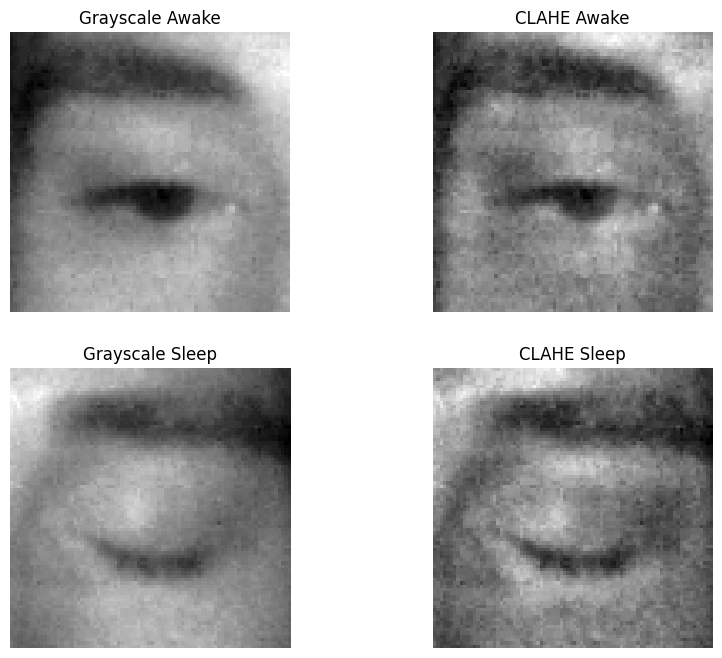

In [12]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced1 = clahe.apply(gray1)
enhanced2 = clahe.apply(gray2)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(gray1,cmap='gray')
plt.title("Grayscale Awake")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(enhanced1,cmap='gray')
plt.title("CLAHE Awake")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(gray2,cmap='gray')
plt.title("Grayscale Sleep")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(enhanced2,cmap='gray')
plt.title("CLAHE Sleep")
plt.axis("off")

plt.show()

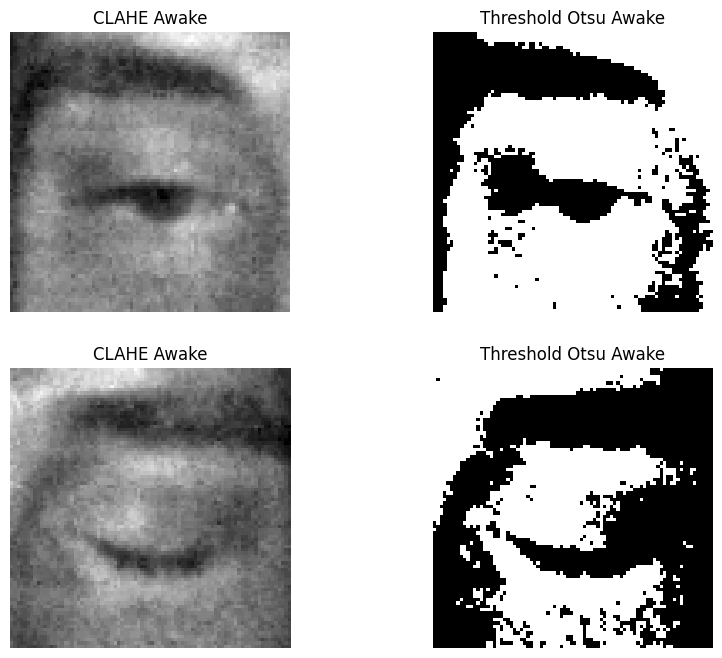

In [13]:
_, thresh1 = cv2.threshold(
    enhanced1,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

_, thresh2 = cv2.threshold(
    enhanced2,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(enhanced1,cmap='gray')
plt.title("CLAHE Awake")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(thresh1,cmap='gray')
plt.title("Threshold Otsu Awake")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(enhanced2,cmap='gray')
plt.title("CLAHE Awake")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(thresh2,cmap='gray')
plt.title("Threshold Otsu Awake")
plt.axis("off")

plt.show()

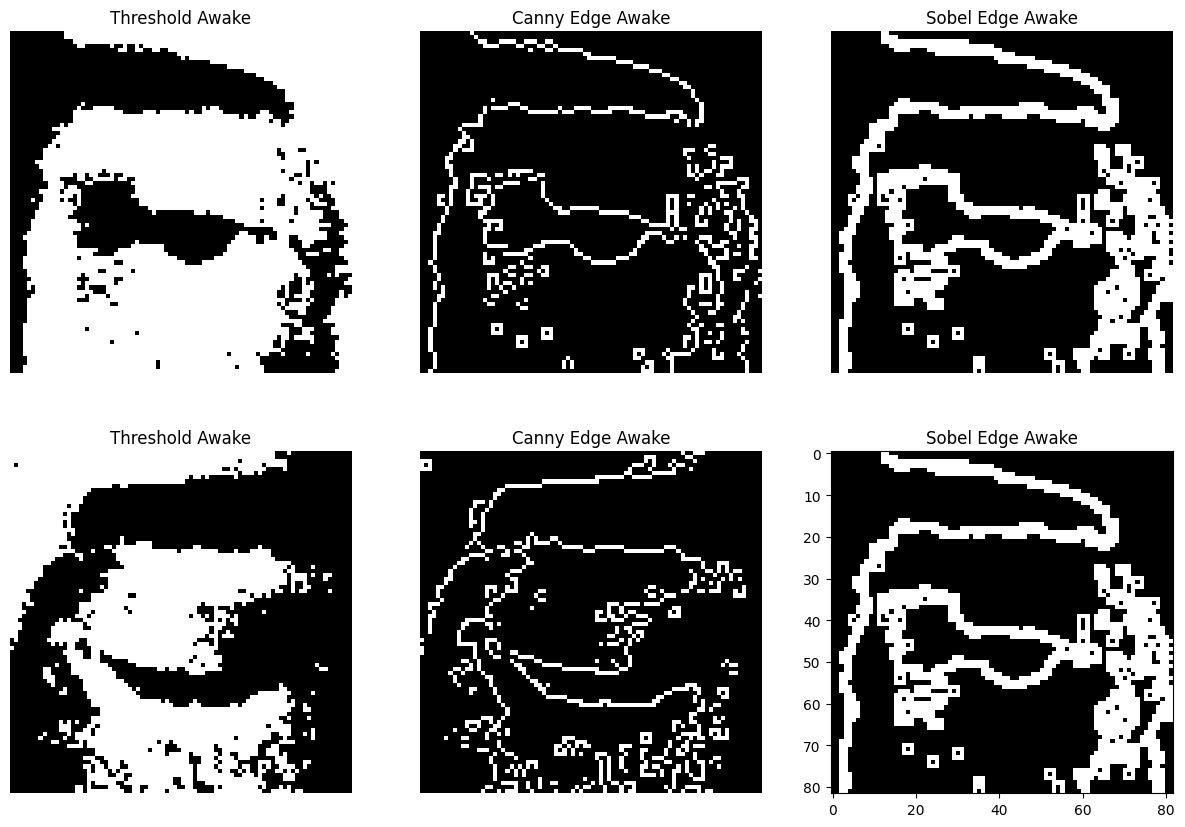

In [14]:
canny1 = cv2.Canny(thresh1,50,150)
canny2 = cv2.Canny(thresh2,50,150)
sobel_x1 = cv2.Sobel(thresh1,cv2.CV_64F,1,0,ksize=3)
sobel_y1 = cv2.Sobel(thresh1,cv2.CV_64F,0,1,ksize=3)
sobel1 = np.sqrt(sobel_x1**2 + sobel_y1**2)
sobel1 = np.uint8(np.clip(sobel1,0,255))
sobel_x2 = cv2.Sobel(thresh1,cv2.CV_64F,1,0,ksize=3)
sobel_y2 = cv2.Sobel(thresh1,cv2.CV_64F,0,1,ksize=3)
sobel2 = np.sqrt(sobel_x2**2 + sobel_y2**2)
sobel2 = np.uint8(np.clip(sobel2,0,255))

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(thresh1,cmap='gray')
plt.title("Threshold Awake")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(canny1,cmap='gray')
plt.title("Canny Edge Awake")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(sobel1,cmap='gray')
plt.title("Sobel Edge Awake")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(thresh2,cmap='gray')
plt.title("Threshold Awake")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(canny2,cmap='gray')
plt.title("Canny Edge Awake")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(sobel2,cmap='gray')
plt.title("Sobel Edge Awake")

plt.show()

## Pre-processing

###### note lecture:
- di prepro tambahin deteksi tepi untuk deteksi bentuk mata, hidung, sama mulut. cuma gatau ini jatuhnya perlu dataset tambahan buat hidung sama mulut atau nggak
- trs tdi juga disaranin buat add threshold?

In [15]:
def base_preprocess_image(file_path):
    img = cv2.imread(file_path)
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clah_img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_img = clah_img.apply(gray_img)
    _, threshold_img = cv2.threshold(enhanced_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return threshold_img

def canny_edge(file_path):
    threshold_img = base_preprocess_image(file_path)
    canny_edges = cv2.Canny(threshold_img, 50, 150)
    resized_img = cv2.resize(canny_edges, (64, 64))
    normalized_img_canny = resized_img / 255.0
    return normalized_img_canny

def sobel_edge(file_path):
    threshold_img = base_preprocess_image(file_path)
    sobel_x = cv2.Sobel(threshold_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(threshold_img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_edges = np.uint8(np.clip(sobel_combined, 0, 255))
    resized_img = cv2.resize(sobel_edges, (64, 64))
    normalized_img_sobel = resized_img / 255.0
    return normalized_img_sobel

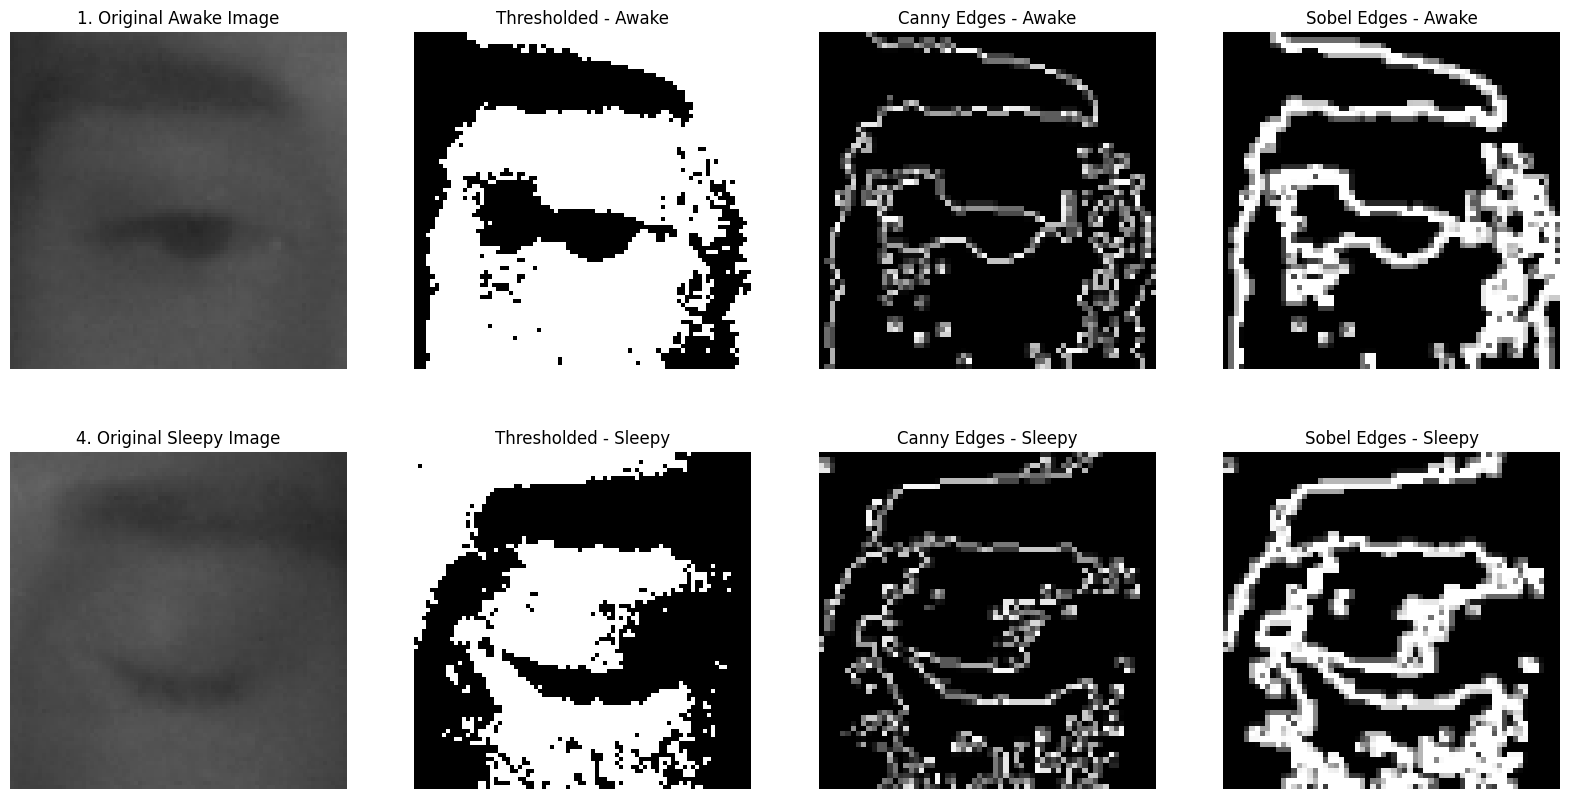

In [16]:
sample_path = "data/train/awake/s0001_01842_0_0_1_0_0_01.png"
sample_sleep= "data/train/sleepy/s0001_00002_0_0_0_0_0_01.png"
if os.path.exists(sample_path):
    img_awake = cv2.imread(sample_path)
    img_awake_rgb = cv2.cvtColor(img_awake, cv2.COLOR_BGR2RGB)
    img_sleepy = cv2.imread(sample_sleep)
    img_sleepy_rgb = cv2.cvtColor(img_sleepy, cv2.COLOR_BGR2RGB)

    thresholded_awake = base_preprocess_image(sample_path)
    thresholded_sleepy = base_preprocess_image(sample_sleep)
    canny_awake = canny_edge(sample_path)
    sobel_awake = sobel_edge(sample_path)
    canny_sleepy = canny_edge(sample_sleep)
    sobel_sleepy = sobel_edge(sample_sleep)

    plt.figure(figsize=(20, 10))

    plt.subplot(2, 4, 1)
    plt.imshow(img_awake_rgb)
    plt.title("1. Original Awake Image")
    plt.axis('off')

    plt.subplot(2, 4, 2)
    plt.imshow(thresholded_awake, cmap='gray')
    plt.title("Thresholded - Awake")
    plt.axis('off')

    plt.subplot(2, 4, 3)
    plt.imshow(canny_awake, cmap='gray')
    plt.title("Canny Edges - Awake")
    plt.axis('off')

    plt.subplot(2, 4, 4)
    plt.imshow(sobel_awake, cmap='gray')
    plt.title("Sobel Edges - Awake")
    plt.axis('off')

    plt.subplot(2, 4, 5)
    plt.imshow(img_sleepy_rgb)
    plt.title("4. Original Sleepy Image")
    plt.axis('off')

    plt.subplot(2, 4, 6)
    plt.imshow(thresholded_sleepy, cmap='gray')
    plt.title("Thresholded - Sleepy")
    plt.axis('off')

    plt.subplot(2, 4, 7)
    plt.imshow(canny_sleepy, cmap='gray')
    plt.title("Canny Edges - Sleepy")
    plt.axis('off')

    plt.subplot(2, 4, 8)
    plt.imshow(sobel_sleepy, cmap='gray')
    plt.title("Sobel Edges - Sleepy")
    plt.axis('off')


    plt.show()
else:
    print(f"sampel tidak ditemukan {sample_path}. cek dan coba lagi.")

## Training

In [17]:
def load_data(data_dir):
    X, y = [], []
    
    tags = {'awake': 1, 'sleepy': 0}
    for tag_name, label in tags.items():
        path_folder = os.path.join(data_dir, tag_name)
        if not os.path.exists(path_folder):
            print(f"folder {path_folder} tidak ditemukan.")
            continue
        for file_name in os.listdir(path_folder):
            if file_name.endswith('.png'):
                file_path=os.path.join(path_folder, file_name)
                try:
                    img = canny_edge(file_path)
                    X.append(img)
                    y.append(label)
                except Exception as e:
                    print(f"gagal memproses {file_path}: {e}")
                    continue

    X = np.array(X).reshape(-1, 64, 64, 1)
    y = np.array(y)
    return X, y

X_train, y_train = load_data("data/train")
X_val, y_val = load_data("data/val")

print(f"Data latih: {X_train.shape}, {y_train.shape}")
print(f"Data validasi: {X_val.shape}, {y_val.shape}")


Data latih: (50937, 64, 64, 1), (50937,)
Data validasi: (16980, 64, 64, 1), (16980,)


In [18]:
model = models.Sequential([
    #layer 1, kovolusi dan pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),

    #layer 2, filter untuk detail kelompok mata
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    #layer 3, pola spasial
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #layer 4, klasifikasi
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    #output
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,329 (794.25 KB)

 Trainable params: 203,329 (794.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
print("training model")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=True
)

print("menyimpan model")


training model
Epoch 1/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 59s 71ms/step - accuracy: 0.8853 - loss: 0.2662 - val_accuracy: 0.9315 - val_loss: 0.1740
Epoch 2/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.9393 - loss: 0.1521 - val_accuracy: 0.9477 - val_loss: 0.1299
Epoch 3/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 54s 67ms/step - accuracy: 0.9582 - loss: 0.1053 - val_accuracy: 0.9538 - val_loss: 0.1132
Epoch 4/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 55s 69ms/step - accuracy: 0.9711 - loss: 0.0750 - val_accuracy: 0.9534 - val_loss: 0.1153
Epoch 5/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.9808 - loss: 0.0512 - val_accuracy: 0.9592 - val_loss: 0.1175
Epoch 6/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 49s 61ms/step - accuracy: 0.9858 - loss: 0.0368 - val_accuracy: 0.9573 - val_loss: 0.1252
Epoch 7/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 51s 64ms/step - accuracy: 0.9896 - loss: 0.0273 - val_accuracy: 0.9598 - val_loss: 0.1307
Epoch 8/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 49s 61ms/step - accuracy: 0.9921 - 

In [20]:
model.save("drowsiness_model.keras")

## Testing

531/531 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9595 - loss: 0.1660
akurasi test: 0.9595, loss test: 0.1660


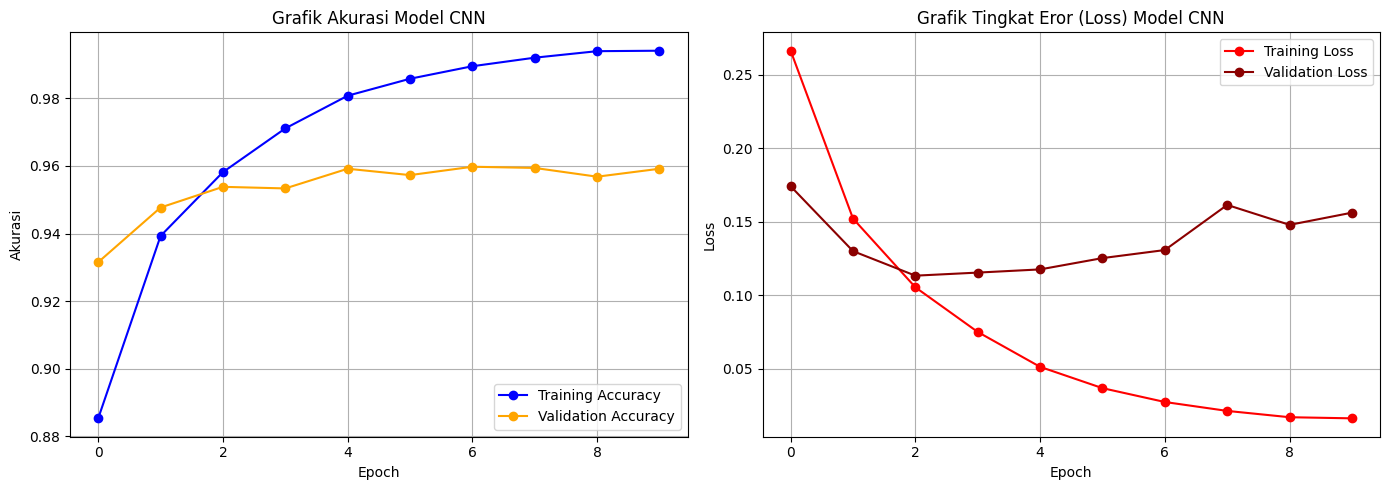

In [21]:
# testing model
X_test, y_test = load_data("data/test")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"akurasi test: {test_acc:.4f}, loss test: {test_loss:.4f}")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('Grafik Akurasi Model CNN')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkred', marker='o')
plt.title('Grafik Tingkat Eror (Loss) Model CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluasi

531/531 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


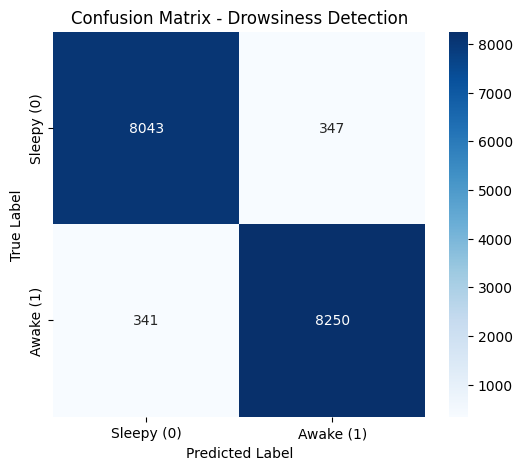

Classification Report:
              precision    recall  f1-score   support

  Sleepy (0)       0.96      0.96      0.96      8390
   Awake (1)       0.96      0.96      0.96      8591

    accuracy                           0.96     16981
   macro avg       0.96      0.96      0.96     16981
weighted avg       0.96      0.96      0.96     16981



In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# 1. Lakukan prediksi pada data test
y_pred_prob = model.predict(X_test)
# Karena output layer menggunakan 'sigmoid' (1 neuron), gunakan threshold 0.5
y_pred = (y_pred_prob > 0.5).astype(int) 

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sleepy (0)', 'Awake (1)'],
            yticklabels=['Sleepy (0)', 'Awake (1)'])
plt.title('Confusion Matrix - Drowsiness Detection')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Tampilkan Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Sleepy (0)', 'Awake (1)']))